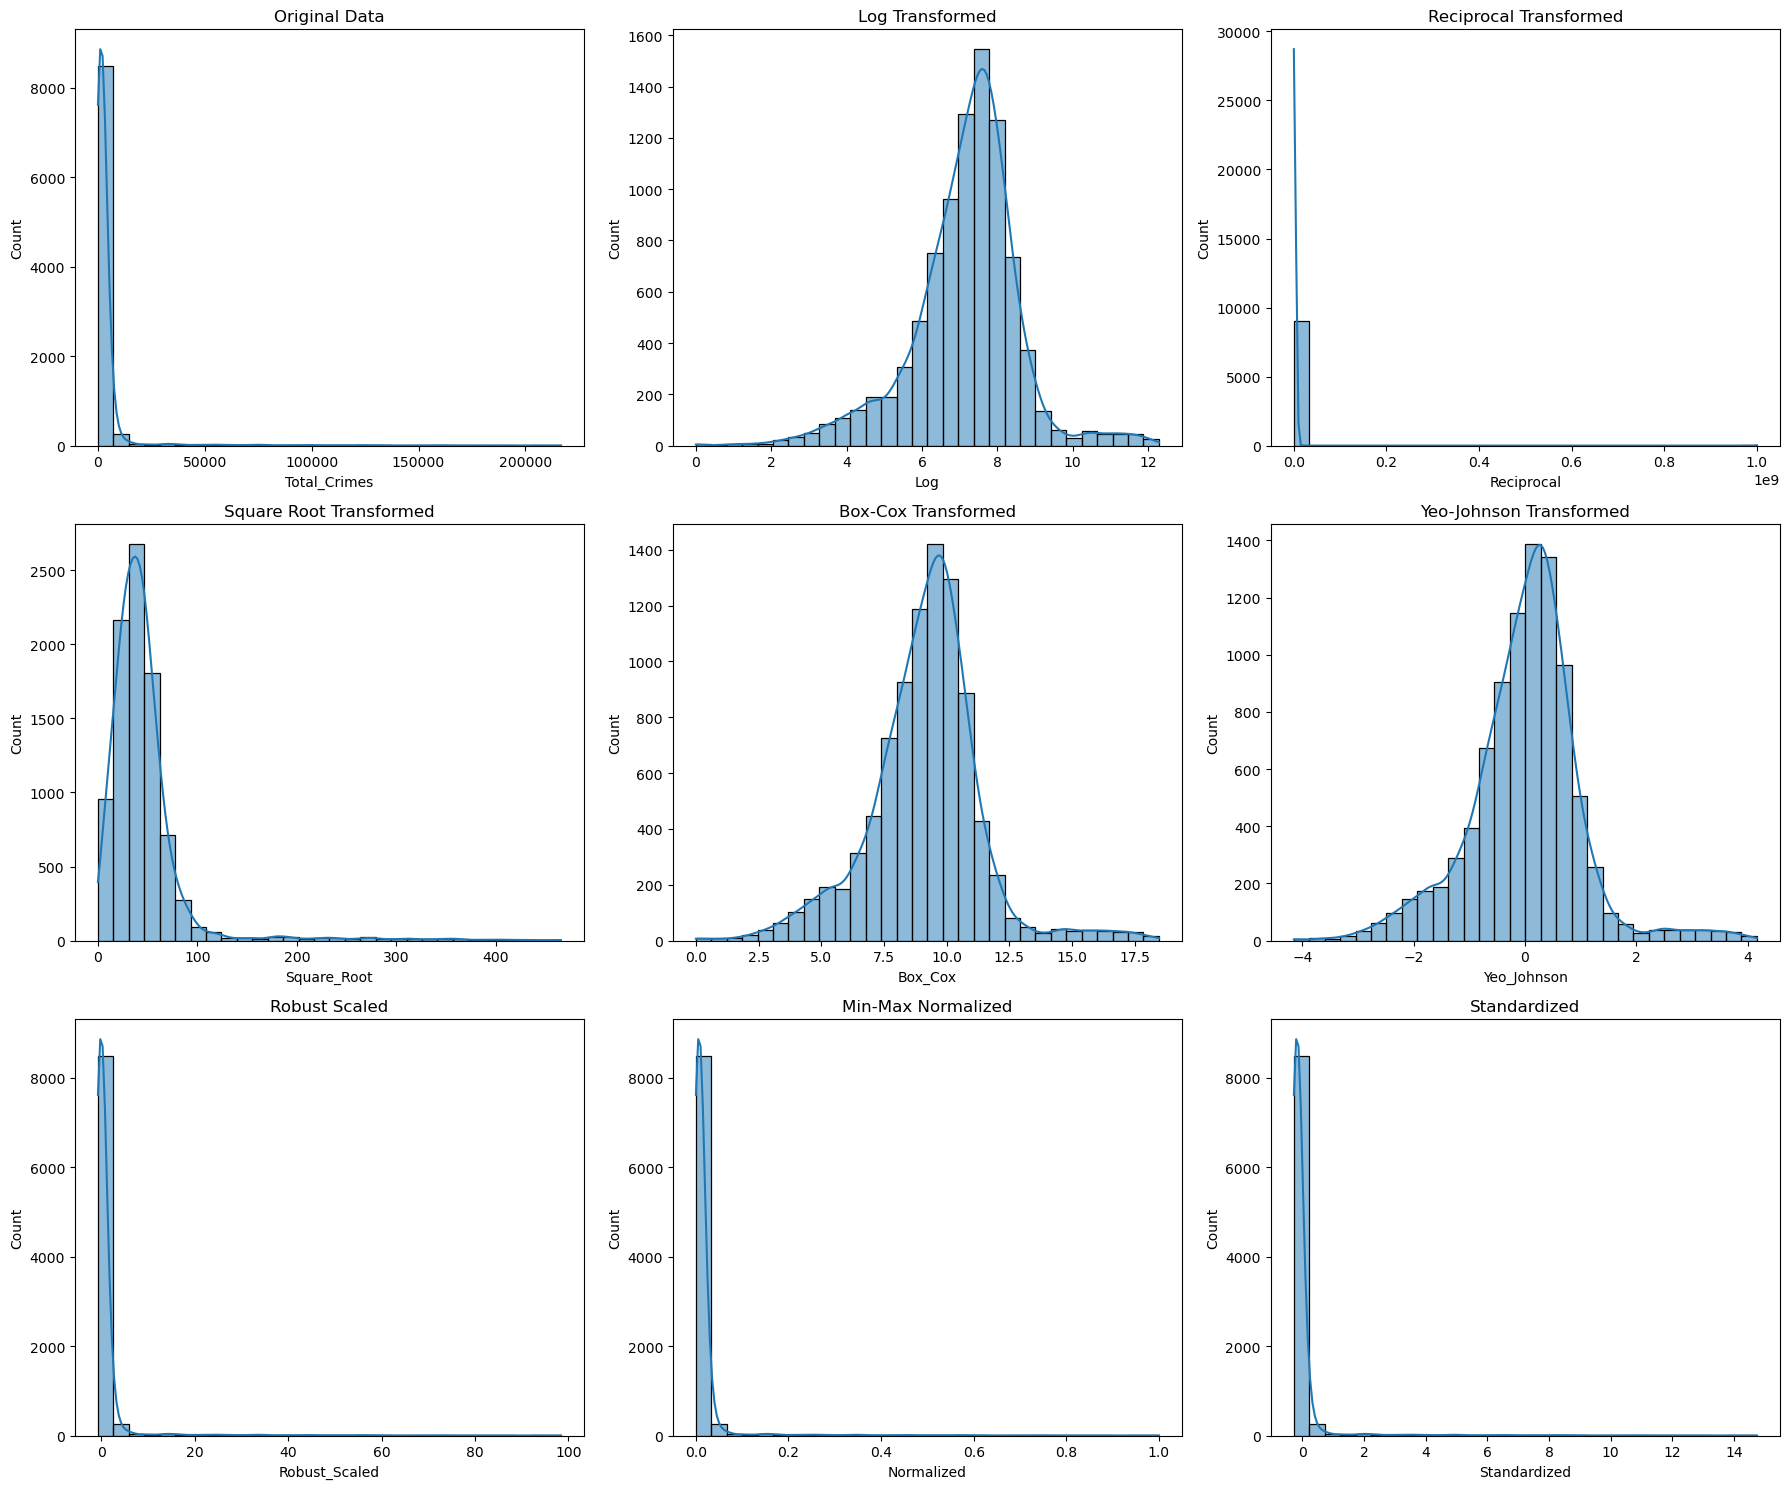

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, RobustScaler, MinMaxScaler, StandardScaler

# =============================
# Load Dataset
# =============================
file_path = r"C:\Users\Dell\Documents\Modified_Crime_Dataset.csv"
data = pd.read_csv(file_path)

# Recreate 'Total_Crimes' column if it doesn't exist
if 'Total_Crimes' not in data.columns:
    crime_columns = data.columns[3:]  # Adjust this based on your dataset
    data['Total_Crimes'] = data[crime_columns].sum(axis=1)

# Select the target variable to transform
target_column = 'Total_Crimes'
df = pd.DataFrame(data[target_column], columns=[target_column])

# =============================
# Apply Transformations
# =============================

# Log Transformation
df['Log'] = np.log1p(df[target_column])  # log(x + 1)

# Reciprocal Transformation
df['Reciprocal'] = 1 / (df[target_column] + 1e-9)  # Avoid division by zero

# Square Root Transformation
df['Square_Root'] = np.sqrt(df[target_column])

# Power Transformations
pt_bc = PowerTransformer(method='box-cox', standardize=False)
df['Box_Cox'] = pt_bc.fit_transform(df[[target_column]].replace(0, 1))  # Box-Cox requires positive data

pt_yj = PowerTransformer(method='yeo-johnson')
df['Yeo_Johnson'] = pt_yj.fit_transform(df[[target_column]])

# =============================
# Apply Scaling Techniques
# =============================

# Robust Scaling
robust_scaler = RobustScaler()
df['Robust_Scaled'] = robust_scaler.fit_transform(df[[target_column]])

# Min-Max Scaling
min_max_scaler = MinMaxScaler()
df['Normalized'] = min_max_scaler.fit_transform(df[[target_column]])

# Standard Scaling
standard_scaler = StandardScaler()
df['Standardized'] = standard_scaler.fit_transform(df[[target_column]])

# Absolute Scaling
df['Abs_Scaled'] = df[target_column] / np.abs(df[target_column]).max()

# =============================
# Visualize Transformations
# =============================

# Create subplots for each transformation
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
sns.histplot(df[target_column], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original Data')

sns.histplot(df['Log'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Log Transformed')

sns.histplot(df['Reciprocal'], bins=30, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Reciprocal Transformed')

sns.histplot(df['Square_Root'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Square Root Transformed')

sns.histplot(df['Box_Cox'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Box-Cox Transformed')

sns.histplot(df['Yeo_Johnson'], bins=30, kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Yeo-Johnson Transformed')

sns.histplot(df['Robust_Scaled'], bins=30, kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Robust Scaled')

sns.histplot(df['Normalized'], bins=30, kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Min-Max Normalized')

sns.histplot(df['Standardized'], bins=30, kde=True, ax=axes[2, 2])
axes[2, 2].set_title('Standardized')

# Adjust layout
plt.tight_layout()
plt.show()
